In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df_raw = pd.read_csv('dataset_0.csv')
print(f"Kích thước tập dữ liệu gốc: {df_raw.shape}")
display(df_raw.head(3))

Kích thước tập dữ liệu gốc: (114000, 21)


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,...,-6.746,0,0.1430,0.0322,0.000001,0.358,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.166,...,-17.235,1,0.0763,0.9240,0.000006,0.101,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.359,...,-9.734,1,0.0557,0.2100,0.000000,0.117,0.120,76.332,4,acoustic


In [25]:
null_counts = df_raw.isnull().sum()
missing_data = pd.DataFrame({'Tổng số dòng rỗng': null_counts, 'Tỷ lệ (%)': (null_counts / len(df_raw)) * 100})
display(missing_data[missing_data['Tổng số dòng rỗng'] > 0])

,Tổng số dòng rỗng,Tỷ lệ (%)
artists,1,0.000877
album_name,1,0.000877
track_name,1,0.000877


In [26]:
features = ['valence', 'energy', 'tempo', 'instrumentalness', 'popularity']
display(df_raw[features].describe())

,valence,energy,tempo,instrumentalness,popularity
count,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,0.474068,0.641383,122.147837,0.156050,33.238535
std,0.259261,0.251529,29.978197,0.309555,22.305078
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.260000,0.472000,99.218750,0.000000,17.000000
50%,0.464000,0.685000,122.017000,0.000042,35.000000
75%,0.683000,0.854000,140.071000,0.049000,50.000000
max,0.995000,1.000000,243.372000,1.000000,100.000000


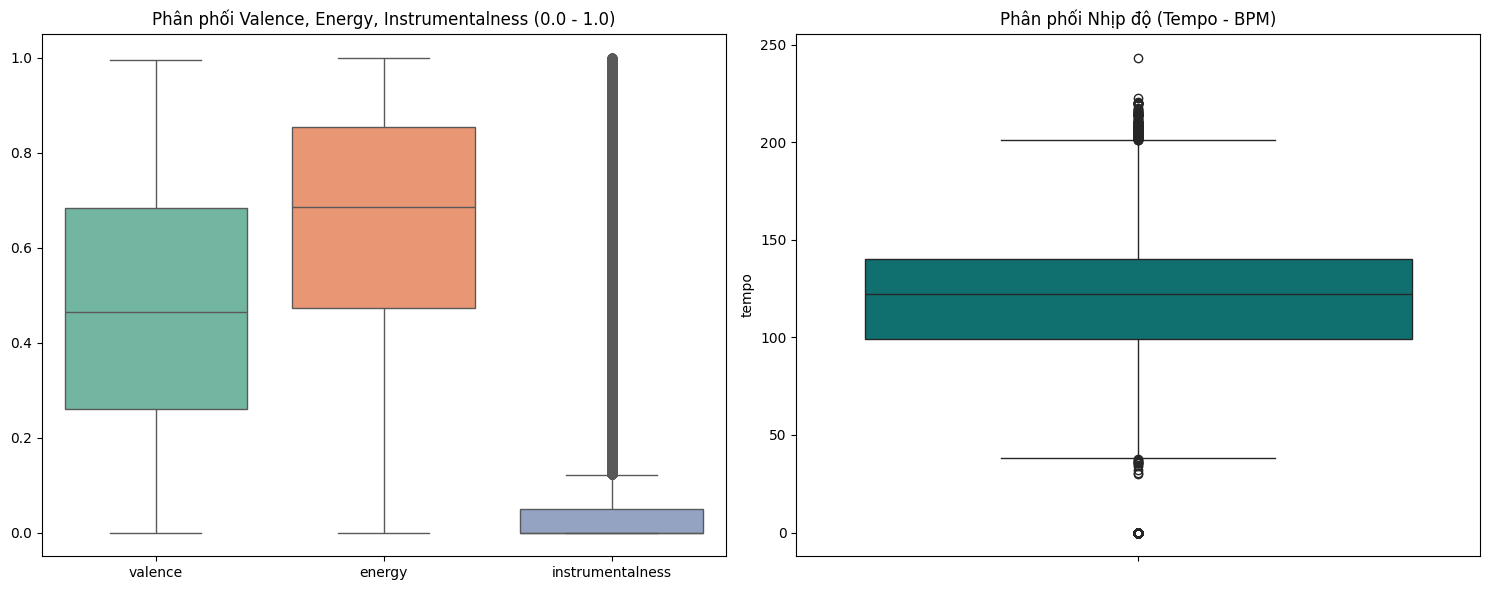

In [27]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.boxplot(data=df_raw[['valence', 'energy', 'instrumentalness']], palette="Set2")
plt.title('Phân phối Valence, Energy, Instrumentalness (0.0 - 1.0)', fontsize=12)

plt.subplot(1, 2, 2)
sns.boxplot(y=df_raw['tempo'], color='teal')
plt.title('Phân phối Nhịp độ (Tempo - BPM)', fontsize=12)

plt.tight_layout()
plt.show()

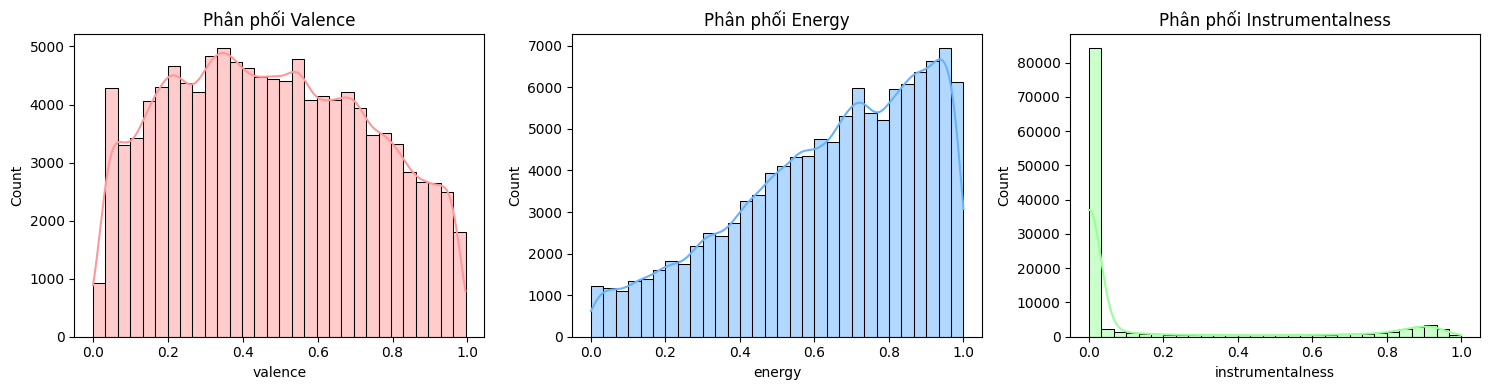

In [28]:
plt.figure(figsize=(15, 4))
colors = ['#FF9999', '#66B2FF', '#99FF99']

for i, col in enumerate(['valence', 'energy', 'instrumentalness']):
    plt.subplot(1, 3, i+1)
    sns.histplot(df_raw[col], bins=30, kde=True, color=colors[i])
    plt.title(f'Phân phối {col.capitalize()}')

plt.tight_layout()
plt.show()

In [29]:
cols_to_check = ['track_id', 'track_name', 'artists', 'track_genre', 'valence', 'energy', 'tempo']
df_clean = df_raw.dropna(subset=cols_to_check).copy()
df_clean = df_clean[df_clean['popularity'] >= 20]
df_clean = df_clean[(df_clean['tempo'] >= 40) & (df_clean['tempo'] <= 200)]
df_clean = df_clean.drop_duplicates(subset=['track_id'])

columns_to_keep = [
    'track_id', 'track_name', 'artists', 'album_name',
    'track_genre', 'popularity', 'valence', 'energy',
    'tempo', 'acousticness', 'instrumentalness'
]
df_clean = df_clean[columns_to_keep]
df_clean = df_clean.rename(columns={'track_genre': 'genre'})
print(f"Kích thước sau Bước 1: {df_clean.shape}")
display(df_clean.head(5))

Kích thước sau Bước 1: (66220, 11)


,track_id,track_name,artists,album_name,genre,popularity,valence,energy,tempo,acousticness,instrumentalness
0,5SuOikwiRyPMVoIQDJUgSV,Comedy,Gen Hoshino,Comedy,acoustic,73,0.715,0.4610,87.917,0.0322,0.000001
1,4qPNDBW1i3p13qLCt0Ki3A,Ghost - Acoustic,Ben Woodward,Ghost (Acoustic),acoustic,55,0.267,0.1660,77.489,0.9240,0.000006
2,1iJBSr7s7jYXzM8EGcbK5b,To Begin Again,Ingrid Michaelson;ZAYN,To Begin Again,acoustic,57,0.120,0.3590,76.332,0.2100,0.000000
3,6lfxq3CG4xtTiEg7opyCyx,Can't Help Falling In Love,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,acoustic,71,0.143,0.0596,181.740,0.9050,0.000071
4,5vjLSffimiIP26QG5WcN2K,Hold On,Chord Overstreet,Hold On,acoustic,82,0.167,0.4430,119.949,0.4690,0.000000


In [30]:
regional_and_noise_genres = [
    'bollywood', 'indian', 'latin', 'latino', 'spanish', 'salsa', 'tango', 'samba', 
    'mandopop', 'cantopop', 'malay', 'turkish', 'iranian', 'french', 'german', 
    'swedish', 'brazil', 'reggaeton', 'afrobeat', 'forro', 'pagode', 'sertanejo',
    'heavy-metal', 'metalcore', 'death-metal', 'black-metal', 'grindcore'
]
bad_tracks = df_clean[df_clean['genre'].isin(regional_and_noise_genres)][['track_name', 'artists']].drop_duplicates()
bad_tracks['is_bad'] = True

df_final = df_clean.merge(bad_tracks, on=['track_name', 'artists'], how='left')
df_final = df_final[df_final['is_bad'].isnull()].drop(columns=['is_bad'])

print(f"Dữ liệu cuối cùng: {df_final.shape}")
df_final.to_csv('cleaned_dataset_final.csv', index=False)
display(df_final.head(5))

Dữ liệu cuối cùng: (49646, 11)


,track_id,track_name,artists,album_name,genre,popularity,valence,energy,tempo,acousticness,instrumentalness
0,5SuOikwiRyPMVoIQDJUgSV,Comedy,Gen Hoshino,Comedy,acoustic,73,0.715,0.4610,87.917,0.0322,0.000001
1,4qPNDBW1i3p13qLCt0Ki3A,Ghost - Acoustic,Ben Woodward,Ghost (Acoustic),acoustic,55,0.267,0.1660,77.489,0.9240,0.000006
2,1iJBSr7s7jYXzM8EGcbK5b,To Begin Again,Ingrid Michaelson;ZAYN,To Begin Again,acoustic,57,0.120,0.3590,76.332,0.2100,0.000000
3,6lfxq3CG4xtTiEg7opyCyx,Can't Help Falling In Love,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,acoustic,71,0.143,0.0596,181.740,0.9050,0.000071
4,5vjLSffimiIP26QG5WcN2K,Hold On,Chord Overstreet,Hold On,acoustic,82,0.167,0.4430,119.949,0.4690,0.000000
